In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rc('font', family='Times New Roman')

masking_forget_path = '/data1/zhaohongbo/exps/forget-CL-backbone-newtry/resultsmaskingsgd-50ep-lr1e-8min0.1/forget_acc.npy'
masking_remain_path = '/data1/zhaohongbo/exps/forget-CL-backbone-newtry/resultsmaskingsgd-50ep-lr1e-8min0.1/remain_acc.npy'

# 导入数据
masking_forget = np.load(masking_forget_path)
masking_remain = np.load(masking_remain_path)
# 在masking_forget中加入一个零，放到第一个位置
masking_forget = np.insert(masking_forget, 0, 0)
masking_remain = np.insert(masking_remain, 0, 74.00)

lora_forget_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr8-lr1e-4/forget_acc.npy'
lora_remain_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr8-lr1e-4/remain_acc.npy'



# 导入数据
lora_forget = np.load(lora_forget_path)
lora_remain = np.load(lora_remain_path)

lora_forget = np.insert(lora_forget, 0, 1.97)
lora_remain = np.insert(lora_remain, 0, 73.18)

# rank 64
lora_forget64_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr64sparser-50ep-lr1e-4/forget_acc.npy'
lora_remain64_path = '/data1/zhaohongbo/exps/forget-CL-backbone/resultsr64sparser-50ep-lr1e-4/remain_acc.npy'

# 导入数据
lora_forget64 = np.load(lora_forget64_path)
lora_remain64 = np.load(lora_remain64_path)

lora_forget64 = np.insert(lora_forget64, 0, 1.39)
lora_remain64 = np.insert(lora_remain64, 0, 72.69)

# baseline，是一个761长度的全为74.63的数组
baseline_forget = np.ones(761) * 73.78
baseline_remain = np.ones(761) * 74.63

In [5]:
length = len(masking_forget)
length #761
len(masking_remain) #761

761

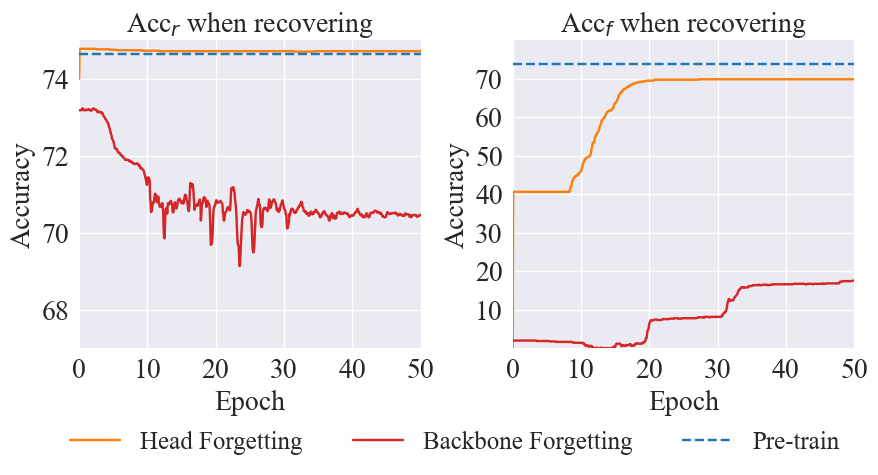

In [10]:
# 绘制图像
fig, (ax1,ax2) = plt.subplots(1,2,sharey=False, figsize=(10, 4))
x = np.linspace(0, 50, len(lora_forget))
ax1.set_xlim(0, 50)
ax1.set_ylim(67, 75)
ax1.set_xlabel('Epoch',fontsize=20)
ax1.set_ylabel('Accuracy',fontsize=20)
# 设置坐标轴刻度
my_x_ticks = np.arange(0, 51, 10)
my_y_ticks = np.arange(70, 74, 2)
ax1.set_xticks(my_x_ticks)

plt.yticks(my_y_ticks)
# 修改坐标轴刻度字体大小
ax1.tick_params(labelsize=20)
ax1.plot(x, masking_remain, label='Head Forgetting', color='#ff7f0e')
ax1.plot(x, lora_remain, label='Backbone Forgetting', color='#d62728')
# ax1.plot(x, lora_remain64, label='GS-LoRA-64', color='#ff7f0e')
ax1.plot(x, baseline_remain, label='Pre-train', color='#1f77b4', linestyle='--')
ax1.set_title('Acc$_r$ when recovering',fontsize=20)


x = np.linspace(0, 50, len(lora_forget))
ax2.set_xlim(0, 50)
ax2.set_ylim(0, 80)
ax2.set_xlabel('Epoch',fontsize=20)
ax2.set_ylabel('Accuracy',fontsize=20)
# 设置坐标轴刻度
my_x_ticks = np.arange(0, 51, 10)
my_y_ticks = np.arange(10, 71, 10)
ax2.set_xticks(my_x_ticks)
ax2.set_yticks(my_y_ticks)
ax2.set_title('Acc$_f$ when recovering',fontsize=20)
# 修改坐标轴刻度字体大小
ax2.tick_params(labelsize=20)
ax2.plot(x, masking_forget, label='Head Forgetting', color='#ff7f0e')
ax2.plot(x, lora_forget, label='Backbone Forgetting', color='#d62728')
# ax2.plot(x, lora_forget64, label='GS-LoRA-64', color='#ff7f0e')
ax2.plot(x, baseline_forget, label='Pre-train', color='#1f77b4', linestyle='--')
ax1.legend(ncol=4, loc='lower center',bbox_to_anchor=(1.1, -0.42),fontsize=18)



plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.27, hspace=None)

plt.savefig('forget.pdf', bbox_inches='tight', dpi=1200)

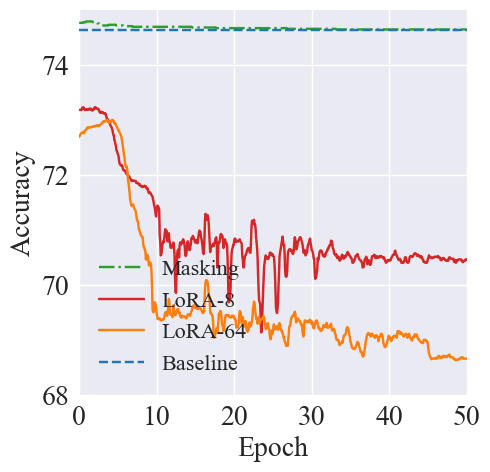

In [11]:

plt.legend(loc='best',fontsize=16)
plt.savefig('remain.pdf', bbox_inches='tight', dpi=1200)